# Clase 3 · Los Cuatro Fantásticos: elegir y construir una arquitectura

No vamos a medir inteligencia contando agentes. Vamos a decidir qué estructura
resuelve una necesidad y a comprobar que no pierde resultados.

**Producto:** un grafo paralelo, un orquestador de workers con plan variable y la
inspección de un agente que usa la herramienta de la clase 1.
Construimos los dos primeros por partes. El agente con herramientas es una demo
guiada; su implementación queda disponible para releer sin memorizarla hoy.

**Recorrido de la clase**

- Clasificar tres necesidades por su forma de trabajo
- Comparar el mapa de arquitecturas y justificar una elección
- Construir estado y workers de un informe paralelo
- Unir ramas sin perder datos y probar el resultado
- Pausa
- Distinguir paralelismo fijo de plan variable
- Construir un orquestador con Send y un reducer
- Observar el bucle de un agente y su límite de llamadas
- Pausa
- Taller: agregar la colección musical al plan
- Comparar resultados y distinguir supervisor de handoff
- Defender una arquitectura con sus límites

**Cómo trabajar:** anticipá una salida, ejecutá una celda, observá y explicá.
La persona que ejecuta y la que revisa intercambian roles durante el reto.
No hay carrera: el criterio es explicar el resultado. Si te perdés, usá el punto
de reenganche más cercano. Las soluciones están después de los retos para poder
volver a ejecutar todo sin dejar celdas rotas.

**Contexto:** las fichas de Batman, los Cuatro Fantásticos y El Chavo son escenarios
inventados para aprender ingeniería, no resúmenes de cómics o episodios reales.
Las canciones son inventadas y solo tienen metadatos: no contienen letras ni audio.
No necesitás conocer estos personajes para resolver las actividades.

**Dos modos:** offline usa búsqueda real y grafos reales, pero sustituye al LLM por
reglas/extractos explícitos. Live usa OpenAI y consume API. El estudiante puede
hacer toda la práctica offline; el docente demuestra live. No compartas el .env.

## La forma del problema importa
Tres pedidos: A) buscar y resumir una ficha; B) consultar dos colecciones independientes;
C) elegir cuántas colecciones consultar según un plan. Dibujá una línea para A,
dos ramas para B y una lista de tareas para C. Todavía no elijas un framework.

Una arquitectura organiza el control y el estado. Puede tener funciones, llamadas
a modelos o agentes. **Dos funciones paralelas no son automáticamente dos agentes.**

In [1]:
from henry_agents.config import configure
from henry_agents.cultural import search_catalog

MODE = configure()
print("Modo de las demos con modelo:", MODE)

Modo de las demos con modelo: offline


## Mapa de arquitecturas: cuándo usar cada una
Estos son patrones que podemos expresar con LangGraph, no botones mágicos ni
categorías excluyentes. Un sistema puede combinar varios.

| Patrón | Quién decide el siguiente paso | Buen uso | Riesgo o costo | Trabajo en este módulo |
|---|---|---|---|---|
| Secuencia / chaining | Orden fijo | Buscar y redactar | Ejecutar pasos innecesarios | Construida en clase 2 |
| Routing | Regla o clasificador | Elegir especialista o abstenerse | Una ruta incorrecta pierde contexto | Construido en clase 2 |
| Paralelismo fijo | Grafo conocido | Dos revisiones independientes | Conflictos al escribir estado | Construimos hoy |
| Orquestador–workers | Plan y reparto de tareas | Número variable de tareas | Duplicados o fan-out sin límite | Construimos hoy |
| Agente con herramientas | Modelo dentro de un bucle | Elegir acciones según observaciones | Loops y gasto | Demo guiada hoy |
| Evaluador–optimizador | Evaluación y criterio de salida | Corregir un borrador verificable | Mejoras aparentes sin progreso | Construimos en clase 4 |
| Supervisor | Coordinador que vuelve a decidir | Delegaciones sucesivas | Cuello de botella central | Comparación de diseño hoy |
| Handoff | Agente que transfiere control | Cambiar responsable de conversación | Perder contexto o permisos | Comparación de diseño hoy |

Checkpointing y revisión humana son capacidades que podemos combinar con estos
patrones. No convierten por sí solos un workflow en un agente.

**Actividad:** una persona elige patrón para A/B/C y la otra pregunta:
“¿Qué evidencia necesitarías para elegir algo más complejo?”. Cambien roles.

## Arquitectura 3: paralelo fijo
Inspiración: el equipo de los Cuatro Fantásticos reúne lecturas independientes.
Nuestro programa comparará evidencia de Batman y Fantásticos sobre herramientas.
No intentamos simular poderes ni razonamientos de los personajes.

```text
          ┌─ worker_batman ─────┐
START ────┤                    ├─ unir ─→ END
          └─ worker_fantasticos ┘
```

Ambos workers leen la misma consulta. Escriben campos distintos: batman y fantasticos.
Así evitamos que uno sobrescriba al otro. El nodo unir debe esperar a ambos.

In [2]:
from typing import TypedDict

from langgraph.graph import END, START, StateGraph


class EstadoParalelo(TypedDict, total=False):
    query: str
    batman: list[str]
    fantasticos: list[str]
    sources: list[str]


def worker_batman(estado):
    resultado = search_catalog(estado["query"], universe="batman", top_k=1)
    return {"batman": [h.id for h in resultado.hits]}


def worker_fantasticos(estado):
    resultado = search_catalog(estado["query"], universe="fantasticos", top_k=1)
    return {"fantasticos": [h.id for h in resultado.hits]}

Antes de conectar, probá cada worker por separado. Si un worker busca en la
colección incorrecta, paralelizarlo solo hace que el error suceda más rápido.
¿Qué esperan obtener al buscar herramientas? BAT-02 y FAN-02.

In [3]:
print(worker_batman({"query": "herramientas"}))
print(worker_fantasticos({"query": "herramientas"}))


def unir(estado):
    return {"sources": sorted(set(estado["batman"] + estado["fantasticos"]))}

{'batman': ['BAT-02']}
{'fantasticos': ['FAN-02']}


## La unión es parte del diseño
La arista con una **lista de nodos de origen** es una barrera: unir espera ambos.
Si cada worker tarda un tiempo independiente t1 y t2, una ejecución ideal paralela
se aproxima a max(t1,t2), más coordinación. No prometemos esa mejora en esta demo
local diminuta; hay overhead y no todo trabajo admite paralelismo.

In [4]:
paralelo = StateGraph(EstadoParalelo)
paralelo.add_node("batman", worker_batman)
paralelo.add_node("fantasticos", worker_fantasticos)
paralelo.add_node("unir", unir)
paralelo.add_edge(START, "batman")
paralelo.add_edge(START, "fantasticos")
paralelo.add_edge(["batman", "fantasticos"], "unir")
paralelo.add_edge("unir", END)
app_paralela = paralelo.compile()
informe = app_paralela.invoke({"query": "herramientas"})
assert set(informe["sources"]) == {"BAT-02", "FAN-02"}
print("Informe conjunto:", informe["sources"])

Informe conjunto: ['BAT-02', 'FAN-02']


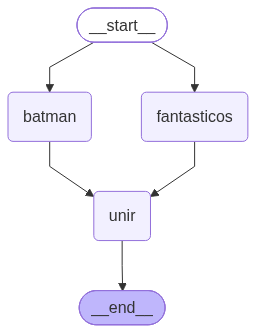

In [5]:
from IPython.display import Image, display
display(Image(app_paralela.get_graph().draw_mermaid_png()))

**Microexperimento:** cambiá query por investigación. Batman tiene evidencia y
Fantásticos puede no tenerla. La unión no debe inventar una fuente para llenar la
rama vacía. Decí qué afirmarías y qué no afirmarías en un informe final.

**Punto de reenganche 1:** podés identificar dos ramas, los campos que escriben
y la barrera de unión. No dependemos del orden en que terminan.

## Pausa

## Arquitectura 4: orquestador–workers
En el paralelo fijo conocíamos las dos tareas. Ahora la entrada trae una lista de
colecciones: puede tener una, dos, tres o cuatro. El plan determina cuántos workers
se crean. `Send` lleva un estado pequeño a cada tarea.

```text
START → validar plan → Send(worker, tarea) × N → reunir → END
```

En esta clase el plan es explícito y validado. En otro sistema podría proponerlo
un LLM con salida estructurada. **No decimos que una lista fija sea planificación
inteligente**: primero aprendemos a ejecutar y verificar el contrato de un plan.

Todos los workers escribirán la misma clave parts. Necesitamos explicar cómo
combinar esas escrituras: un reducer recibe lo anterior y lo nuevo y los combina.

In [6]:
import operator
from typing import Annotated

from langgraph.types import Send

print("Reducer de listas:", operator.add(["BAT-02"], ["FAN-02"]))


class EstadoEquipo(TypedDict, total=False):
    query: str
    universes: list[str]
    parts: Annotated[list[dict], operator.add]
    summary: str

Reducer de listas: ['BAT-02', 'FAN-02']


operator.add concatena listas; no elimina duplicados ni las ordena. Por eso
normalizamos el plan antes de enviarlo. El orden de llegada de workers no es un
contrato para la presentación final: ordenamos explícitamente al reunir.

## Construimos el plan, el reparto y la reunión
Cada función tiene una responsabilidad pequeña. El worker recibe query y universe,
no toda la conversación ni credenciales. Reducir el contexto facilita probarlo.

In [8]:
def planificar(estado):
    permitidas = {"batman", "fantasticos", "chavo", "canciones"}
    pedidas = estado["universes"]
    if not pedidas or not set(pedidas) <= permitidas:
        raise ValueError("Plan vacío o colección desconocida")
    return {"universes": sorted(set(pedidas))}


def repartir(estado):
    return [Send("worker", {"query": estado["query"], "universe": u}) for u in estado["universes"]]


def worker(estado):
    resultado = search_catalog(estado["query"], universe=estado["universe"], top_k=1)
    return {"parts": [{"universe": estado["universe"], "ids": [h.id for h in resultado.hits]}]}

In [9]:
def reunir(estado):
    partes = sorted(estado["parts"], key=lambda parte: parte["universe"])
    return {"summary": "\n".join(f"{p['universe']}: {p['ids']}" for p in partes)}


equipo = StateGraph(EstadoEquipo)
equipo.add_node("planificar", planificar)
equipo.add_node("worker", worker)
equipo.add_node("reunir", reunir)
equipo.add_edge(START, "planificar")
##################################################################
### Acá es donde cambia ####
equipo.add_conditional_edges("planificar", repartir, ["worker"])
##################################################################
equipo.add_edge("worker", "reunir")
equipo.add_edge("reunir", END)
app_equipo = equipo.compile()
plan = {"query": "equipo", "universes": ["fantasticos", "chavo"], "parts": []}
resultado = app_equipo.invoke(plan)
assert len(resultado["parts"]) == 2
print(resultado["summary"])

chavo: ['CHA-01']
fantasticos: ['FAN-01']


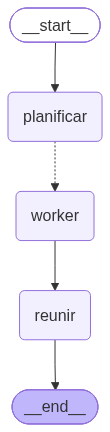

In [10]:
display(Image(app_equipo.get_graph().draw_mermaid_png()))

**Comprobación de comprensión:** ¿qué pasa si duplicamos chavo en el plan?
Debe ejecutarse una sola tarea para esa colección, porque planificar deduplica.
¿Qué pasaría sin reducer si varios workers escribieran parts? LangGraph detectaría
actualizaciones incompatibles en la misma clave; no debemos ocultarlo con un try genérico.

## Arquitectura 5: agente con herramientas
Ahora cambia quién decide: el modelo propone acciones, observa resultados y decide
si ya puede responder. El grafo controla el bucle y sus límites.

```text
START → modelo ── respuesta final ─→ END
           │
           └─ tool call → herramienta ─→ modelo
```

El módulo implementa AgentState con add_messages, ToolNode y un contador. Al llegar
al máximo de llamadas termina con un mensaje de límite. recursion_limit es una
segunda defensa del runtime, no un presupuesto de dinero.
La demo offline es un guion; live sí consulta el modelo. Registramos acciones y
observaciones, no pedimos cadenas privadas de pensamiento.

In [13]:
from langchain_core.messages import HumanMessage, ToolMessage

from henry_agents.cultural import build_tool_agent

agente = build_tool_agent(MODE, max_calls=1)
estado_agente = agente.invoke(
    {"messages": [HumanMessage(content="Busca investigación de Batman")], "calls": 0},
    config={"recursion_limit": 12},
)
assert any(isinstance(m, ToolMessage) for m in estado_agente["messages"])
print("Llamadas al modelo o guion:", estado_agente["calls"])
print("Respuesta final:", estado_agente["messages"][-1].content)

Llamadas al modelo o guion: 1
Respuesta final: Límite de llamadas: revisar con una persona.


In [15]:
cond = input('define el maximo # de llamadas')
cond = int(cond)
agente = build_tool_agent(MODE, max_calls=cond)
estado_agente = agente.invoke(
    {"messages": [HumanMessage(content="Busca investigación de Batman")], "calls": 0},
    config={"recursion_limit": 12},
)
assert any(isinstance(m, ToolMessage) for m in estado_agente["messages"])
print("Llamadas al modelo o guion:", estado_agente["calls"])
print("Respuesta final:", estado_agente["messages"][-1].content)

define el maximo # de llamadas 1


Llamadas al modelo o guion: 1
Respuesta final: Límite de llamadas: revisar con una persona.


**Punto de reenganche 2:** compará una arista fija con la decisión de llamar una
herramienta. Si todos los pasos fueran conocidos, ¿qué costo extra agrega un agente?

## Pausa

## Taller: el equipo prepara una actividad y su música
Agregá canciones al plan de cooperación sin crear un nodo nuevo.

1. Anticipá cuántos workers se crearán para fantástico + chavo + canciones.
2. Ejecutá y comprobá que parts conserve una contribución por colección.
3. Duplicá una colección y demostrá que no aparece un worker extra.
4. Probá una colección desconocida: debe rechazarse, no aceptarse silenciosamente.

**Pista 1:** se modifica universes; la topología permanece igual.
**Pista 2:** compará conjuntos de universe y cantidad de parts.
**Entrega:** un plan, su resumen y una justificación de usar Send en lugar de copiar nodos.
La celda siguiente es el punto de partida con dos colecciones. Modificá su lista
y comprobá tu predicción antes de avanzar a la solución de tres colecciones.

In [ ]:
mi_plan = {
    "query": "cooperación",
    "universes": ["fantasticos", "chavo"],
    "parts": [],
}
mi_equipo = app_equipo.invoke(mi_plan)
print(mi_equipo["summary"])

## Solución y crítica de arquitectura
El conjunto de dominios y el conteo permiten detectar pérdida o duplicación. La
síntesis no debe transformar una lista vacía en una afirmación inventada.
Comparamos una solución completa con tu variante. Las cuatro entradas de la lista
crean tres tareas: el plan normalizado elimina la repetición de chavo.

In [ ]:
plan_solucion = {
    "query": "cooperación",
    "universes": ["fantasticos", "chavo", "canciones", "chavo"],
    "parts": [],
}
equipo_solucion = app_equipo.invoke(plan_solucion)
esperadas = {"fantasticos", "chavo", "canciones"}
assert {p["universe"] for p in equipo_solucion["parts"]} == esperadas
assert len(equipo_solucion["parts"]) == 3
print(equipo_solucion["summary"])
try:
    app_equipo.invoke({"query": "equipo", "universes": ["internet"], "parts": []})
    raise AssertionError("El plan debía rechazarse")
except ValueError:
    print("Plan desconocido rechazado.")

### Supervisor y handoff: no son lo mismo
**Supervisor:** el coordinador recibe el resultado de un especialista y vuelve a
decidir. Podría pedir a Batman más evidencia y luego pedir a otro especialista una
comparación. El control regresa al centro; hay que limitar delegaciones.

**Handoff:** el responsable actual transfiere el control y contexto al siguiente.
En una analogía de la vecindad, quien recibe el recado incompleto lo deriva a quien
puede confirmar la hora; no vuelve a decidir todo desde el principio. En LangGraph,
Command(update=..., goto=...) puede expresar actualización más transferencia.

| Pregunta | Supervisor | Handoff |
|---|---|---|
| ¿Quién decide luego del especialista? | El coordinador | El nuevo responsable |
| ¿Qué contrato necesita? | Tarea y resultado | Contexto, motivo y responsabilidad |
| ¿Qué error debemos probar? | Delegación infinita | Transferencia circular o pérdida de contexto |

Hoy los comparamos en diseño, no afirmamos haber implementado un supervisor o un
handoff conversacional completo. Orquestar workers con un plan es otra decisión.

**Discusión:** si solo queremos dos IDs, no necesitamos un supervisor.
¿Qué requisito nuevo justificaría agregarlo? Escribí el requisito antes del patrón.

## Ticket de salida
Elegí una arquitectura para “comparar evidencia de tres colecciones y recomendar
una canción”. Dibujá dónde viaja el estado, qué se ejecuta simultáneamente y quién
une resultados. Nombrá un caso de error y cómo lo probarías.

**Criterio de logro:** justificás el patrón por la tarea, no por parecer más avanzado.
En la clase 4 agregamos revisión, ciclos acotados y una decisión humana.